Load the relevant packages and the Load the titanic dataset from the csv

In [308]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
titanic = pd.read_csv("../data/Titanic-Dataset.csv")

Visualize the first few rows of the dataset

In [309]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Get a statistical summary of the dataset

In [310]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Lets check for the missing values 

In [311]:
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

From the data above we can tell we have missing values in Age, Cabin and Embarked columns respectively. Get the percentage of missing values per column 

In [312]:
titanic.isna().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

Handle the missing values in Age in the titanic dataset

In [313]:
titanic["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

We check for the skewness of the age , to determine if to fill the missing values using using mean or median

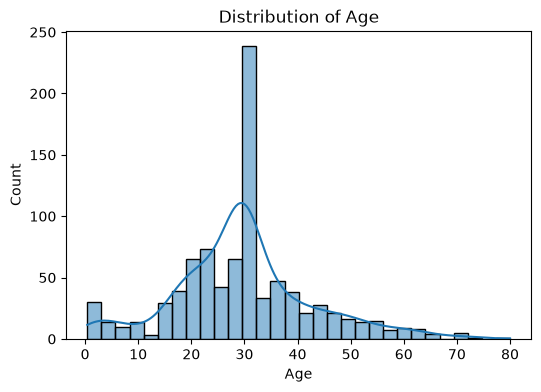

In [384]:
plt.figure(figsize=(6,4))
sns.histplot(titanic["Age"], kde=True)
plt.title("Distribution of Age")
plt.show()

In [315]:
titanic["Age"].skew()

np.float64(0.38910778230082704)

The Age column had approximately 19.9% missing values. Instead of dropping the column, the missing values were imputed using the mean age because the distribution was only slightly positively skewed (skewness ≈ 0.39), and the mean and median were close (29.7 vs. 28.0), indicating that the mean is a suitable measure of central tendency.

In [316]:
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].mean(), inplace=True)

/tmp/ipykernel_111659/291222775.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic["Age"] = titanic["Age"].fillna(titanic["Age"].mean(), inplace=True)


Next handle the missing values in cabin

In [317]:
titanic["Cabin"].isna().mean() * 100

np.float64(77.10437710437711)

The Cabin column was removed because approximately 77% of its values were missing. In addition, the column contained many unique cabin identifiers, making meaningful imputation impractical and likely to introduce bias.

In [318]:
titanic = titanic.drop(columns=["Cabin"])

Handle the missing values for the Embarked column. Since its an object or are character, we use the mode to fill in the missing values

In [319]:
titanic["Embarked"].mode()

0    S
Name: Embarked, dtype: str

In [320]:
titanic = titanic.fillna({"Embarked": "S"})


In [321]:
titanic.isna().mean() * 100

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

Hnadle duplicates in the titanic dataset

In [322]:
titanic.duplicated().sum()

np.int64(0)

The titanic dataset has no duplicates, hence we move to the next phase which is to perform univariate and bivariate analysis. 

Univariate analysis , starting with the survived column

Describe the column

In [323]:
titanic["Survived"].describe()

count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64

In [324]:
titanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [325]:
titanic["Survived"].mode()

0    0
Name: Survived, dtype: int64

In [326]:
titanic["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

From the dataset the titanic had 891 passengers, 549 (61.61%) of whom did not survive and 342(38.4%) survived and the data type of the column is float and the the mode is 0, meaning more people drowned than survived

Visualize the survived column

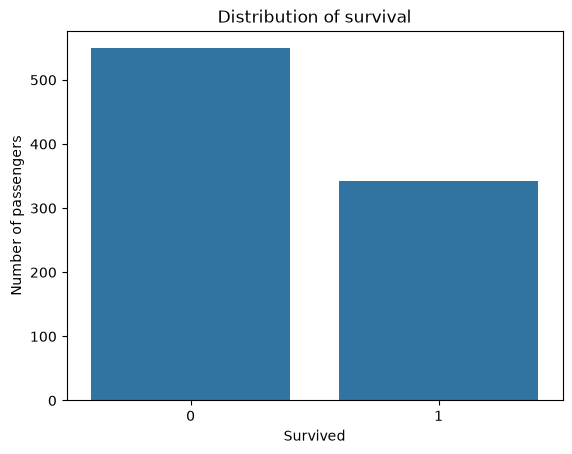

In [327]:
sns.countplot(x="Survived", data=titanic)
plt.ylabel("Number of passengers")
plt.title("Distribution of survival")
plt.show()

In [328]:
titanic["Survived"].skew()

np.float64(0.4785234382949897)

The skew is 0.4785234382949897 which makes it a right leaning skew

We can conclude the survived variable is a binary categorical feature indicating whether a passenger survived (1) or not (o). Out of 891 passengers, 61.6% did not survive, while 38.4% survived.

Univariate analysis of Passenger class

In [329]:
titanic["Pclass"].describe()

count    891.000000
mean       2.308642
std        0.836071
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        3.000000
Name: Pclass, dtype: float64

In [330]:
titanic["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [331]:
titanic["Pclass"].value_counts(normalize=True) * 100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

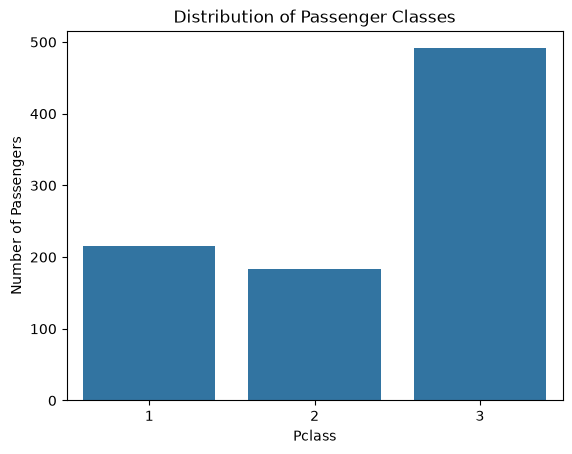

In [332]:
sns.countplot(x="Pclass", data=titanic)
plt.ylabel("Number of Passengers")
plt.title("Distribution of Passenger Classes")
plt.show()

The passenger class is a float variable , the total number of passnegers was 891 with 491(55.11%) in the third class, 216(24.24%) passengers in the first class and 184 passengers in the second class. The modal class is the third class

Univariate analysis of the sex column

In [333]:
titanic["Sex"].describe()

count      891
unique       2
top       male
freq       577
Name: Sex, dtype: object

In [334]:
titanic["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [335]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Univariate Analysis of Age

In [336]:
titanic["Age"].describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

From the describe method, age is a float variable with a mean of 29.699

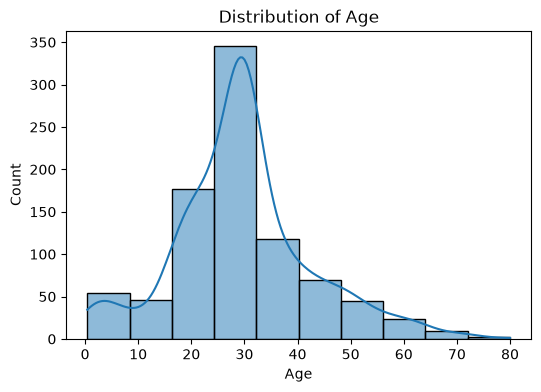

In [337]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Age",bins=10, kde=True)
plt.title("Distribution of Age")
plt.show()

In [338]:
titanic["Age"].skew()

np.float64(0.4344880940129925)

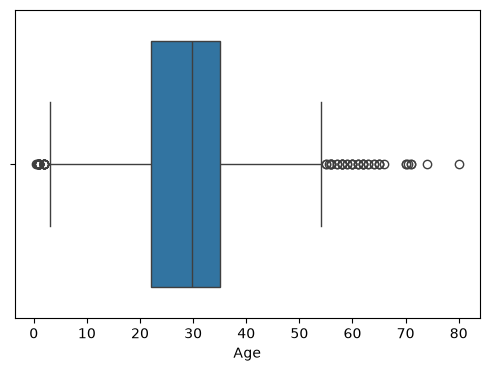

In [339]:
plt.figure(figsize=(6,4))
sns.boxplot(data=titanic, x="Age")
plt.show()

The `Age` variable is a continuous numerical feature. Based on the descriptive statistics, the average passenger age is approximately **29.7 years**, with a standard deviation of **13.0 years**, indicating moderate variability in passenger ages. The ages range from **0.42 years** to **80 years.
:
The histogram with the Kernel Density Estimate (KDE) shows that the age distribution is **slightly positively (right) skewed**, which is supported by a skewness coefficient of **0.434**. Most passengers are concentrated between the lower and middle age ranges, with relatively fewer older passengers.

The boxplot reveals the presence of several **upper-end outliers**, representing a small number of passengers with ages substantially higher than the majority of the dataset. A ion of **13.0 years**, indicating moderate variability in passenger ages. The ages range from **0.42 years** to **80 years.few lower-end outliers are also present, corresponding to very young passengers. Despite these outliers, the overall distribution exhibits only a slight positive skew.


Univariate analysis of SibSp(Siblings and spouse)

In [340]:
titanic["SibSp"].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

In [341]:
titanic["SibSp"].sum()

np.int64(466)

In [342]:
titanic["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [343]:
titanic["SibSp"].value_counts(normalize=True) * 100

SibSp
0    68.237935
1    23.456790
2     3.142536
4     2.020202
3     1.795735
8     0.785634
5     0.561167
Name: proportion, dtype: float64

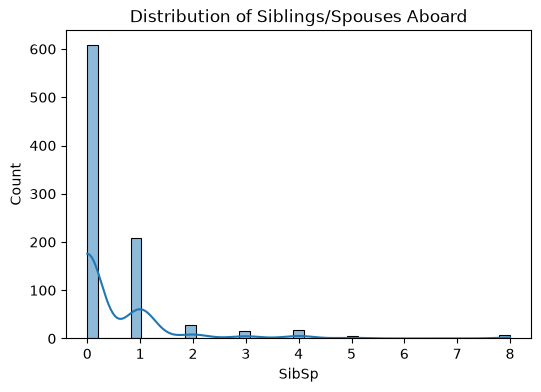

In [344]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="SibSp", kde=True)
plt.title("Distribution of Siblings/Spouses Aboard")
plt.show()  

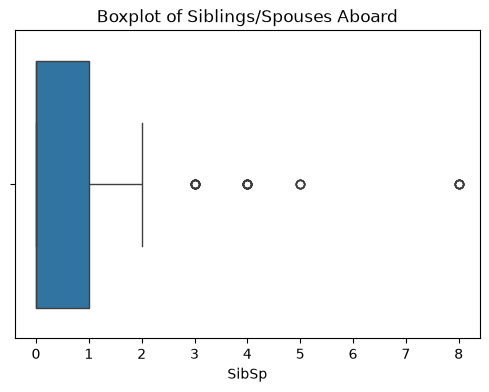

In [385]:
plt.figure(figsize=(6,4))
sns.boxplot(data=titanic, x="SibSp")
plt.title("Boxplot of Siblings/Spouses Aboard")
plt.show()

In [346]:
titanic["SibSp"].skew()

np.float64(3.6953517271630565)

The **SibSp** variable is a numerical feature representing the number of siblings and/or spouses accompanying a passenger aboard the Titanic. Although it is stored as a numeric (float) data type, it is a **discrete count variable** rather than a continuous variable.

The frequency distribution shows that the majority of passengers travelled without siblings or spouses. Specifically, **608 passengers (68.24%)** had no siblings or spouses on board. **209 passengers (23.45%)** had one sibling or spouse, while **28 passengers (3.14%)** had two. Additionally, **16 passengers (1.80%)** had three siblings or spouses, **18 passengers (2.02%)** had four, **5 passengers (0.56%)** had five, and **7 passengers (0.79%)** had eight.

Overall, the distribution indicates that most passengers travelled either alone or with only one sibling or spouse. Only a small number of passengers had large family groups, resulting in a **positively (right) skewed** distribution. This is supported by the skewness value of **3.695**, which indicates a strong right skew caused by a few passengers with unusually high **SibSp** values.


Univariate analysis of the Parch column

In [347]:
titanic["Parch"].describe()

count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64

In [348]:
titanic["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

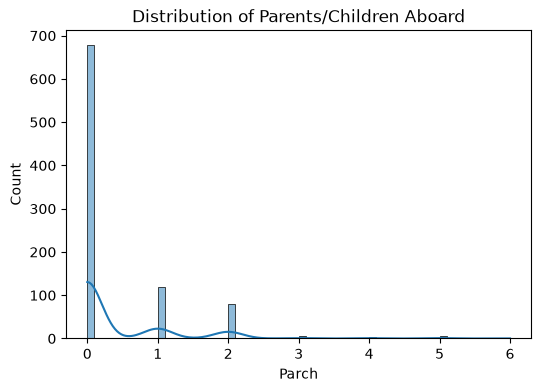

In [386]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Parch", kde=True)
plt.title("Distribution of Parents/Children Aboard")
plt.show()

In [350]:
titanic["Parch"].skew()

np.float64(2.7491170471010933)

The Parch variable is a discrete numerical feature representing the number of parents and/or children accompanying a passenger aboard the Titanic. The descriptive statistics show that most passengers travelled without parents or children, with a median and 75th percentile of 0. Specifically, 678 passengers (76.09%) had no parents or children on board, while 118 (13.24%) had one and 80 (8.98%) had two. Only a few passengers had three or more, making these relatively uncommon. The histogram confirms that the distribution is positively (right) skewed, with a skewness of 2.75, indicating that the majority of passengers had no accompanying parents or children, while a small number travelled with larger family groups.

Univariate analysis of fare

In [351]:
titanic["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

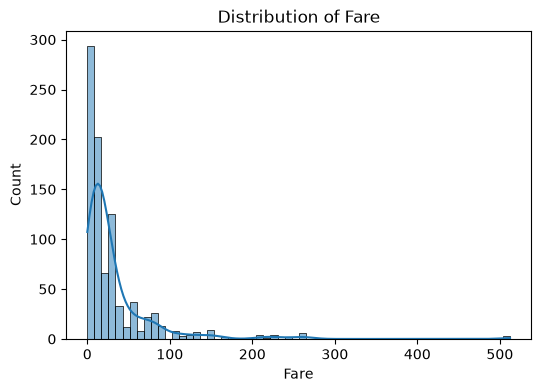

In [352]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Fare", kde=True)
plt.title("Distribution of Fare")
plt.show()

In [353]:
titanic["Fare"].skew()

np.float64(4.787316519674893)

The Fare variable is a continuous numerical feature representing the ticket fare paid by each passenger. The average fare was 32.20, with a median of 14.45, indicating that more than half of the passengers paid relatively low fares. The fares ranged from 0.00 to 512.33, with a standard deviation of 49.69, suggesting considerable variability in ticket prices. The histogram shows a strong positive (right) skew, with most passengers paying lower fares and a small number paying exceptionally high fares. This is supported by the skewness value of 4.79, indicating the presence of several high-value outliers.

In [354]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Univariate Analysis of the Embarked column

In [355]:
titanic["Embarked"].describe()

count     891
unique      3
top         S
freq      646
Name: Embarked, dtype: object

In [356]:
titanic["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [357]:
titanic["Embarked"].value_counts(normalize=True) * 100

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: proportion, dtype: float64

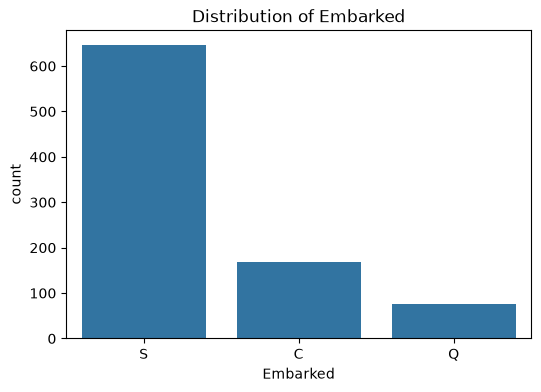

In [387]:
plt.figure(figsize=(6, 4))
sns.countplot(data=titanic, x="Embarked")
plt.title("Distribution of Embarked")
plt.show()

The `Embarked` variable is a categorical feature representing the port from which each passenger boarded the Titanic. It contains three unique embarkation ports: **Southampton (S)**, **Cherbourg (C)**, and **Queenstown (Q)**. The most common embarkation port is **Southampton (S)**, with **646 passengers** embarking from this location. The count plot shows that Southampton contributed the largest proportion of passengers, while Cherbourg and Queenstown had considerably fewer passengers.


Bivariate analysis of the titanic dataset

Bivariate analysis of survived and Pclass

In [359]:
titanic.groupby("Pclass")["Survived"].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [360]:
pd.crosstab(
    titanic["Pclass"],
    titanic["Survived"]
)

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


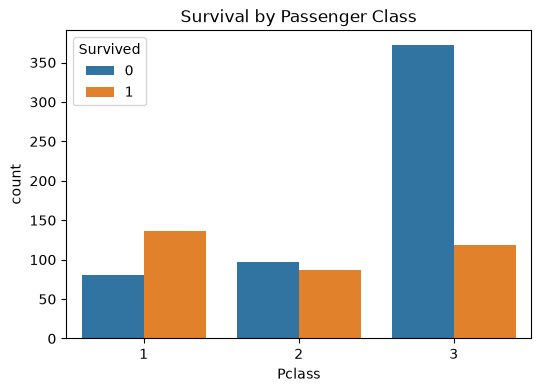

In [388]:
plt.figure(figsize=(6,4))
sns.countplot(data=titanic, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

The bivariate analysis of Survival against passenger class reveals that the survival of passengers was affected by the class in which they were. The first class had the most survivals 62.96% which is 136 people while the second class had 47.28% survial rate which is 87 people. The third class had 24.24% survival rate which was 119 people. From the analysis of survial against passenger, passengers were most likely to survive in the first class than in second and the third class.

Bivariate analysis of survival against sex

In [362]:
titanic.groupby("Sex")["Survived"].mean() * 100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [363]:
pd.crosstab(titanic["Sex"], titanic["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


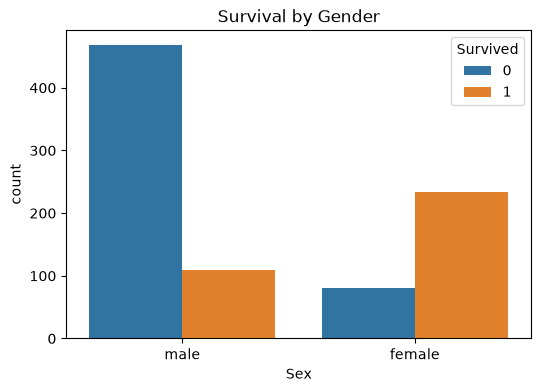

In [389]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=titanic, hue="Survived")
plt.title("Survival by Gender")
plt.show()

Analysis of survival against sex reveals that the sex of the passengers determined the rate of survial. More females survived than males despite theri being more males than females on the titanic. 74% (233) of all the females survived while only 18%(109) of males survived.

Analysis of survival based on age

In [365]:
titanic.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,30.415100,12.457370,1.00,23.0,29.699118,35.0,74.0
1,342.0,28.549778,13.772498,0.42,21.0,29.699118,35.0,80.0


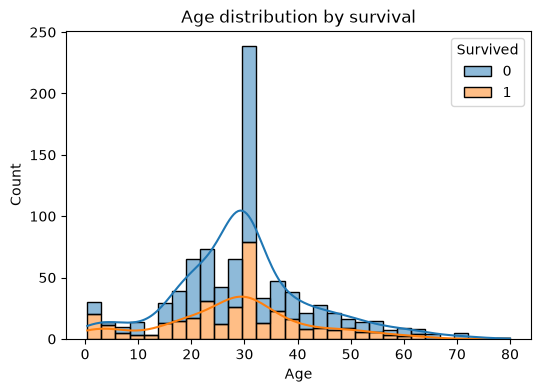

In [366]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Age", kde=True, hue="Survived", multiple="stack")
plt.title("Age distribution by survival")
plt.show()

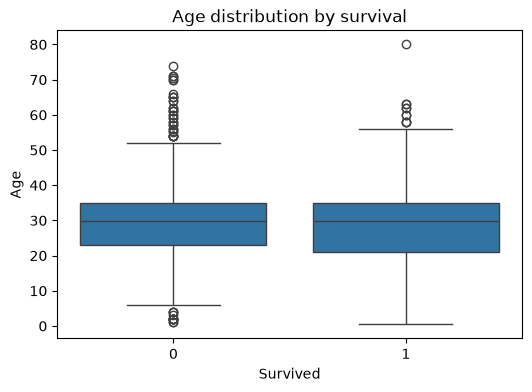

In [367]:
plt.figure(figsize=(6,4))
sns.boxplot(data=titanic, x="Survived", y="Age")
plt.title("Age distribution by survival")
plt.show()

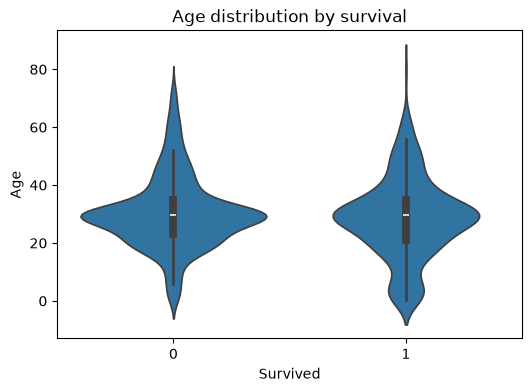

In [368]:
plt.figure(figsize=(6,4))
sns.violinplot(
    data=titanic,
    x="Survived",
    y="Age"
)
plt.title("Age distribution by survival")
plt.show()

The average age of passengers who did not survive (30.4 years) was slightly higher than that of survivors (28.5 years). However, the difference is relatively small. The histogram and boxplot show substantial overlap between the age distributions of survivors and non-survivors, suggesting that age alone was not a strong determinant of survival. While very young passengers are present among survivors, passengers across a wide range of ages both survived and perished.

Analysis of survival based on SibSp

In [369]:
titanic.groupby("SibSp")["Survived"].mean() * 100

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64

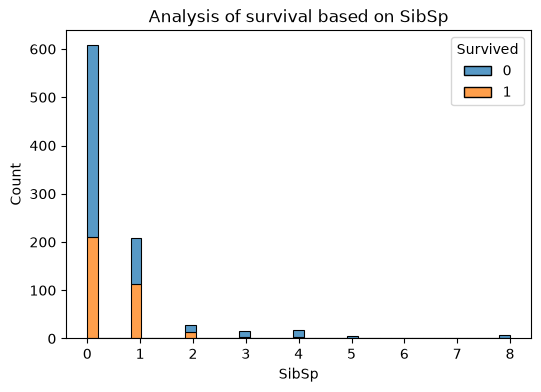

In [390]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="SibSp", hue="Survived", multiple="stack")
plt.title("Analysis of survival based on SibSp")
plt.show()

The relationship between SibSp and Survived suggests that family size may have influenced survival. Passengers traveling with one sibling or spouse had the highest survival rate (53.6%), while passengers traveling alone had a lower survival rate (34.5%). Survival rates generally declined as the number of siblings or spouses increased beyond one. However, the categories representing larger family sizes contain very few passengers, making those estimates less reliable. Overall, the results suggest that traveling with a small family may have been associated with a higher likelihood of survival, whereas traveling with a large family was associated with lower survival rates.

Analysis of survival based on Parents and children (Parch)

In [371]:
titanic.groupby("Parch")["Survived"].describe()

,count,mean,std,min,25%,50%,75%,max
Parch,,,,,,,,
0,678.0,0.343658,0.475279,0.0,0.0,0.0,1.0,1.0
1,118.0,0.550847,0.499529,0.0,0.0,1.0,1.0,1.0
2,80.0,0.500000,0.503155,0.0,0.0,0.5,1.0,1.0
3,5.0,0.600000,0.547723,0.0,0.0,1.0,1.0,1.0
4,4.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
5,5.0,0.200000,0.447214,0.0,0.0,0.0,0.0,1.0
6,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.0


In [372]:
titanic.groupby("Parch")["Survived"].mean() * 100

Parch
0    34.365782
1    55.084746
2    50.000000
3    60.000000
4     0.000000
5    20.000000
6     0.000000
Name: Survived, dtype: float64

In [373]:
titanic.groupby("Parch")["Survived"].sum()

Parch
0    233
1     65
2     40
3      3
4      0
5      1
6      0
Name: Survived, dtype: int64

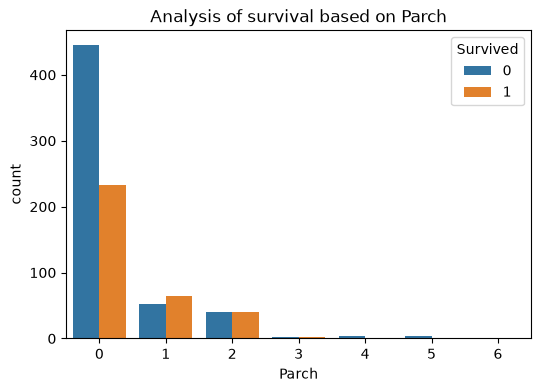

In [391]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=titanic,
    x="Parch",
    hue="Survived"
)
plt.title("Analysis of survival based on Parch")
plt.show()

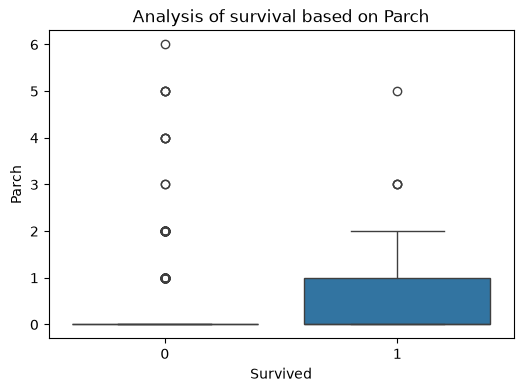

In [375]:
plt.figure(figsize=(6,4))
sns.boxplot(data=titanic, x="Survived", y="Parch")
plt.title("Analysis of survival based on Parch")
plt.show()

The bivariate analysis indicates a noticeable association between Parch and passenger survival. Passengers travelling without a parent or child aboard the Titanic (Parch = 0) had the lowest survival rate among the major groups (34.37%). In contrast, passengers travelling with one or two parents or children exhibited substantially higher survival rates of 55.08% and 50.00%, respectively. The count plot further shows that most passengers travelled without parents or children, while the boxplot indicates that non-survivors were concentrated in the Parch = 0 category. Although the survival rate for Parch = 3 appears highest (60%), this category contains only five passengers, making the estimate unreliable. Similarly, categories with Parch values of 4, 5, and 6 contain very few observations and should not be used to draw general conclusions. Overall, the analysis suggests that travelling with a small family group (one or two parents/children) was associated with a higher likelihood of survival compared to travelling without parents or children, while conclusions for larger family groups remain uncertain due to limited sample sizes.

Analysis of survival based on Fare

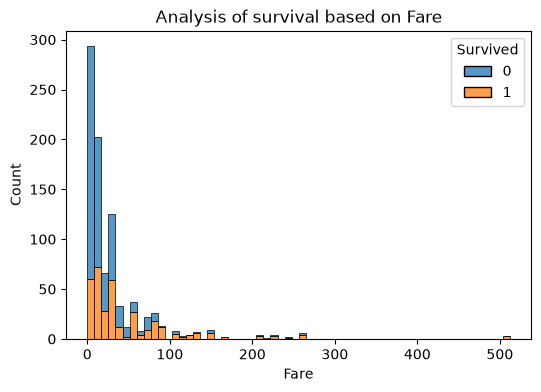

In [376]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Fare", hue="Survived", multiple="stack")
plt.title("Analysis of survival based on Fare")
plt.show()

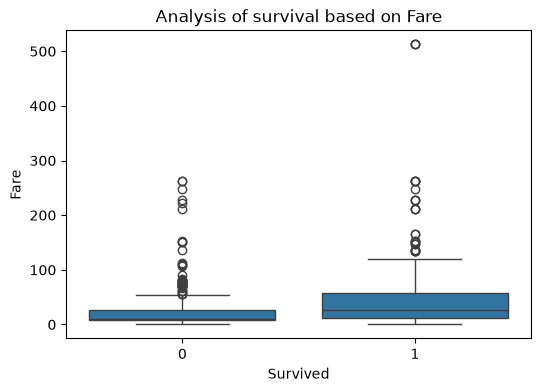

In [377]:
plt.figure(figsize=(6,4))
sns.boxplot(data=titanic, x="Survived", y="Fare") 
plt.title("Analysis of survival based on Fare")
plt.show()

The bivariate analysis suggests a positive association between ticket fare and passenger survival. The histogram shows that non-survivors were concentrated within the lower fare ranges, whereas survivors were more prevalent among passengers who paid higher fares. The boxplot further supports this observation by showing that survivors had a higher median fare, a wider spread of fares, and more high-fare outliers than non-survivors. Overall, the analysis indicates that passengers who paid higher fares were generally more likely to survive, although this association may also reflect other related factors such as passenger class.

Analysis of survival based on Embarked

In [378]:
titanic.groupby("Embarked")["Survived"].sum()

Embarked
C     93
Q     30
S    219
Name: Survived, dtype: int64

In [379]:
titanic.groupby("Embarked")["Survived"].mean() * 100

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

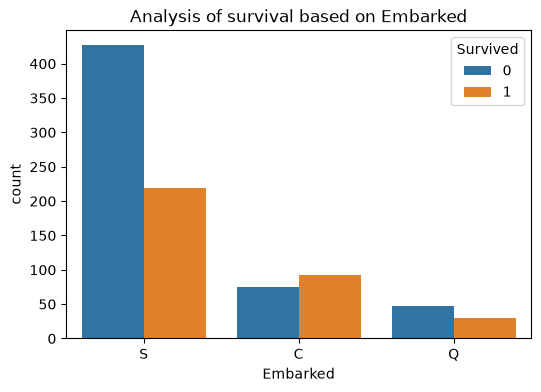

In [380]:
plt.figure(figsize=(6,4))
sns.countplot(data=titanic, x="Embarked", hue="Survived")
plt.title("Analysis of survival based on Embarked")
plt.show()

The bivariate analysis indicates an association between passengers' port of embarkation and survival. Passengers who boarded at Cherbourg (C) had the highest survival rate (55.36%), followed by Queenstown (Q) at 38.96%, while passengers embarking from Southampton (S) had the lowest survival rate (33.90%). Although Southampton recorded the largest number of survivors (219), it also had the largest number of passengers overall, resulting in a lower survival rate than the other ports. The count plot supports these findings by showing that Southampton contributed the majority of passengers, whereas Cherbourg exhibited a more balanced distribution of survivors and non-survivors. Overall, the analysis suggests that the port of embarkation was associated with differences in passenger survival, although this relationship may also reflect other factors such as passenger class and ticket fare.

Distributions and correlations

In [381]:
numeric = titanic.select_dtypes(include="number")
numeric.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


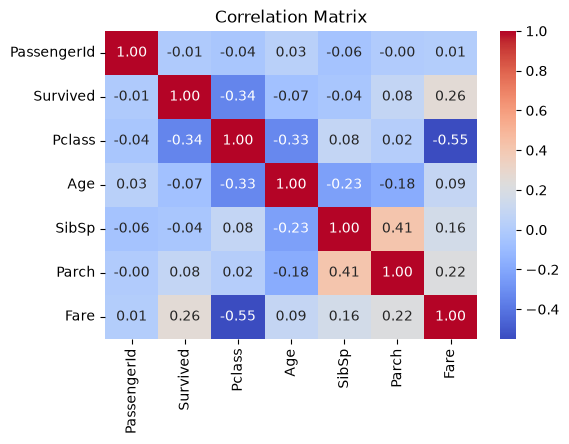

In [392]:
plt.figure(figsize=(6,4))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

The correlation matrix was computed to examine the strength and direction of the linear relationships between the numerical variables in the Titanic dataset. Correlation coefficients range from -1 to +1, where values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values close to 0 indicate little or no linear relationship.

Key Findings
Pclass and Fare (-0.55) exhibit the strongest negative correlation in the dataset. This indicates that passengers in higher classes (lower class number) generally paid higher ticket fares, while passengers in lower classes paid lower fares.
SibSp and Parch (0.41) show a moderate positive correlation, suggesting that passengers travelling with siblings or spouses were also likely to be travelling with parents or children, reflecting family travel patterns.
Survived and Pclass (-0.34) have a moderate negative correlation, indicating that passengers travelling in higher classes were generally more likely to survive.
Survived and Fare (0.26) show a weak positive correlation, suggesting that passengers who paid higher fares tended to have a higher likelihood of survival.
Age and Pclass (-0.33) exhibit a moderate negative correlation, indicating that older passengers were more likely to travel in higher passenger classes.
Age and SibSp (-0.23) and Age and Parch (-0.18) show weak negative correlations, suggesting that younger passengers were slightly more likely to travel with family members.
Fare and Parch (0.22) and Fare and SibSp (0.16) display weak positive correlations, indicating that passengers travelling with family members tended to pay slightly higher fares.
Age and Fare (0.09), Survived and Age (-0.07), Survived and SibSp (-0.04), PassengerId with all other variables, and several other pairs exhibit very weak or negligible correlations, indicating little or no linear relationship.

Overall Conclusion

The correlation analysis indicates that Passenger Class (Pclass), Fare, and Survival are the most strongly related numerical variables in the dataset. In particular, passengers travelling in higher classes generally paid higher fares and exhibited greater survival rates. Family-related variables (SibSp and Parch) are moderately correlated, reflecting the tendency for family members to travel together. Most other variable pairs demonstrate weak or negligible linear relationships, suggesting that they contribute relatively little to explaining one another individually.

In [383]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Important Features

PassengerId, Name and Ticket are identifier variables and do not directly contribute to predicting passenger survival. These variables may become useful after feature engineering, but in their current form they provide little predictive value.

Passenger Class (Pclass)

Passenger class is one of the strongest predictors of survival. Bivariate analysis showed that first-class passengers had substantially higher survival rates than second- and third-class passengers. The moderate negative correlation (-0.34) between Pclass and Survival further supports this relationship.

Conclusion: Pclass is an important predictive feature.

Sex

Passenger sex exhibits the strongest relationship with survival in the dataset. Female passengers experienced considerably higher survival rates than male passengers, suggesting that gender played a significant role during evacuation.

Conclusion: Sex is one of the most important features for predicting survival.

Age

Although younger passengers appear to have had a slightly higher survival rate, the distributions of survivors and non-survivors overlap considerably. The weak negative correlation (-0.07) indicates that age alone is not a strong predictor of survival.

Conclusion: Age has limited predictive power when considered independently.

Fare

Passengers paying higher ticket fares generally exhibited higher survival rates. The positive correlation (0.26) together with the boxplots and histograms suggests that fare is associated with passenger survival, likely because it reflects passenger class.

Conclusion: Fare is an important predictive feature.

SibSp

Passengers travelling with one sibling or spouse generally exhibited higher survival rates than those travelling alone or in very large families. However, the relationship is inconsistent across all SibSp values.

Conclusion: SibSp has moderate predictive value but is not a strong standalone feature.

Parch

Passengers travelling with one to three parents or children generally experienced higher survival rates than passengers travelling alone or in very large family groups.

Conclusion: Parch provides useful predictive information, although its effect is weaker than that of Sex or Pclass.

Embarked

Passengers embarking from Cherbourg (C) demonstrated higher survival rates than passengers embarking from Southampton (S) or Queenstown (Q). This suggests that the embarkation port contains useful predictive information, although its influence may partly reflect differences in passenger class.

Conclusion: Embarked is a moderately useful predictive feature.

## Overall Conclusion

Exploratory Data Analysis of the Titanic dataset revealed several factors associated with passenger survival. Passenger sex emerged as the strongest predictor, with female passengers exhibiting significantly higher survival rates than male passengers. Passenger class also demonstrated a strong relationship with survival, with first-class passengers experiencing substantially better survival outcomes than those travelling in lower classes.

Fare displayed a positive association with survival, suggesting that passengers paying higher ticket fares were generally more likely to survive. Family-related variables (SibSp and Parch) showed that passengers travelling in small family groups tended to have higher survival rates than those travelling alone or in very large groups. Embarkation port also exhibited differences in survival, with passengers embarking from Cherbourg recording the highest survival rate.

Correlation analysis further confirmed the importance of passenger class and fare while indicating that age had only a weak linear relationship with survival. Overall, the most influential features identified during this analysis are Sex, Pclass, Fare, Embarked, Parch and SibSp. These variables would be the most valuable candidates for building a predictive machine learning model for passenger survival.